### Import Packages

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import statsmodels.api as sm
from scipy.optimize import minimize
from functools import *
import eikon as ek

# Set API key
ek.set_app_key('f707dc9f51db4ed29792538cacc4960dfe8a8fad')

try:
    data = ek.get_timeseries("AAPL.O", fields="CLOSE", start_date="2024-01-01", end_date="2024-02-01")
    print(data)
except Exception as e:
    print(f"Error: {e}")

2025-03-07 19:47:54,340 P[19848] [MainThread 7953816640] Error: no proxy address identified.
Check if Eikon Desktop or Eikon API Proxy is running.
2025-03-07 19:47:54,342 P[19848] [MainThread 7953816640] Port number was not identified, cannot send any request
2025-03-07 19:47:54,344 P[19848] [MainThread 7953816640] Port number was not identified.
Check if Eikon Desktop or Eikon API Proxy is running.


EikonError: Error code -1 | Port number was not identified. Check if Eikon Desktop or Eikon API Proxy is running.

### Import Dataset and Merge on Date

In [2]:
### Import Dataset and Merge on Date
stock_files = {
    'BAC': 'BAC.csv',
    'BLK': 'BLK.csv',
    'JPM': 'JPM.csv',
    'BRK-A': 'BRK-A.csv',
    'CME': 'CME.csv',
    'CG': 'CG.csv',
    'MS-PF': 'MS-PF.csv',
}

# Load and preprocess stock data
def load_stock_data(filename, ticker):
    df = pd.read_csv(filename, parse_dates=['Date'], dayfirst=True)
    df = df[(df['Date'] >= '2013-01-01') & (df['Date'] <= '2019-12-31')]
    if 'Adj Close' in df.columns:
        df = df[['Date', 'Adj Close']].rename(columns={'Adj Close': ticker})
    else:
        df = df[['Date', 'Adjusted Close']].rename(columns={'Adjusted Close': ticker})
    return df

# Merge all stock data, keeping Date as the index
dataset = None
for ticker, file in stock_files.items():
    stock_df = load_stock_data(file, ticker)
    if dataset is None:
        dataset = stock_df.set_index('Date')
    else:
        dataset = dataset.merge(stock_df.set_index('Date'), left_index=True, right_index=True, how='inner')

# Load Fama-French 3-Factor Data
ff_3f = pd.read_csv('ff3.csv', parse_dates=['Date'])
ff_3f = ff_3f[(ff_3f['Date'] >= '2013-01-01') & (ff_3f['Date'] <= '2019-12-31')].set_index('Date')

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_2128/528081738.py:14: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(filename, parse_dates=['Date'], dayfirst=True)


### Calculate individual stock returns, covariance, risk-free rate

In [3]:
returns = dataset.pct_change().dropna()  # Index is now Date (datetime64[ns])
mean_returns_annualized = returns.mean() * 252 
print(mean_returns_annualized)

BAC      0.181172
BLK      0.132657
JPM      0.197244
BRK-A    0.120988
CME      0.214201
CG       0.120071
MS-PF    0.077647
dtype: float64


In [4]:
cov_matrix_annualized = returns.cov() * 252 
print(cov_matrix_annualized)

            BAC       BLK       JPM     BRK-A       CME        CG     MS-PF
BAC    0.062484  0.036684  0.044461  0.024566  0.021708  0.031255  0.001764
BLK    0.036684  0.047095  0.031420  0.023368  0.018415  0.031575  0.001974
JPM    0.044461  0.031420  0.041801  0.022185  0.019346  0.026947  0.001406
BRK-A  0.024566  0.023368  0.022185  0.024131  0.014887  0.018608  0.001115
CME    0.021708  0.018415  0.019346  0.014887  0.036629  0.011912 -0.000094
CG     0.031255  0.031575  0.026947  0.018608  0.011912  0.088669  0.003124
MS-PF  0.001764  0.001974  0.001406  0.001115 -0.000094  0.003124  0.004255


In [7]:
rf_rate = ff_3f['RF'].mean() * 252 
print(rf_rate)

0.7086606129398411


### Now, lets calculate the optimal portfolio weights
1. SLSQP minimizes a function of several variables with any combination of bounds, equality and inequality constraints. 
2. SLSQP is ideal for mathematical problems for which the objective function and the constraints are twice continuously differentiable. 
 <\br> https://docs.quantum.ibm.com/api/qiskit/0.41/qiskit.algorithms.optimizers.SLSQP

In [ ]:
### Portfolio Optimization
def objective(weights):
    portfolio_return = np.dot(weights, mean_returns_annualized)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annualized, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_volatility
    return -sharpe_ratio

max_weight = 0.8
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
bounds = [(0, max_weight) for _ in range(len(returns.columns))]
initial_guess = np.ones(len(returns.columns)) / len(returns.columns)
result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = result.x

# Portfolio metrics
portfolio_return_annualized = np.dot(optimal_weights, mean_returns_annualized)
portfolio_volatility_annualized = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix_annualized, optimal_weights)))

# Print results
print(f"Optimal Portfolio Weights: {dict(zip(returns.columns, np.round(optimal_weights, 4)))}")
print(f"Portfolio Expected Return (Annualized): {portfolio_return_annualized:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility_annualized:.4f}")


# Weight - depend on correlation 
# Input - correlation matrix, make the matrix diagonal 

Optimal Portfolio Weights: {'BAC': 0.8, 'BLK': 0.0, 'JPM': 0.2, 'BRK-A': 0.0, 'CME': 0.0, 'CG': 0.0, 'MS-PF': 0.0}
Portfolio Expected Return (Annualized): 0.1844
Portfolio Volatility (Annualized): 0.2364


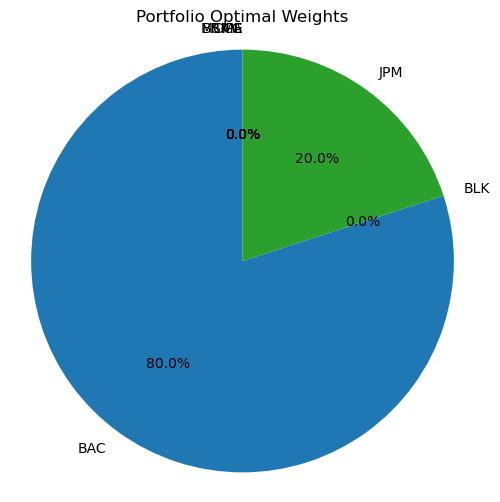

In [10]:
# +Pie Chart of Optimal Weights
plt.figure(figsize=(6, 6))
plt.pie(optimal_weights, labels=returns.columns, autopct='%1.1f%%', startangle=90)
plt.title("Portfolio Optimal Weights")
plt.axis('equal')
plt.show()

In [22]:
# Diversified Portfolio 

def objective(weights):
    portfolio_return = np.dot(weights, mean_returns_annualized)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annualized, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_volatility
    return -sharpe_ratio  # We maximize Sharpe Ratio by minimizing its negative value

# Constraints
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})  # Sum of weights must be 1

# Bounds: Each weight should be between a small positive value (e.g., 1%) and 50%
min_weight = 0.01  # Ensures every stock gets invested in
max_weight = 0.50  # No stock should exceed 50%
bounds = [(min_weight, max_weight) for _ in range(len(returns.columns))]

# Initial guess: Equal weight allocation
initial_guess = np.ones(len(returns.columns)) / len(returns.columns)

# Optimization
result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = result.x

# Portfolio metrics
portfolio_return_annualized = np.dot(optimal_weights, mean_returns_annualized)
portfolio_volatility_annualized = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix_annualized, optimal_weights)))

# Print results
print(f"Optimal Portfolio Weights: {dict(zip(returns.columns, np.round(optimal_weights, 4)))}")
print(f"Portfolio Expected Return (Annualized): {portfolio_return_annualized:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility_annualized:.4f}")

Optimal Portfolio Weights: {'BAC': 0.45, 'BLK': 0.01, 'JPM': 0.01, 'BRK-A': 0.01, 'CME': 0.01, 'CG': 0.5, 'MS-PF': 0.01}
Portfolio Expected Return (Annualized): 0.1490
Portfolio Volatility (Annualized): 0.2259


In [26]:
# Portfolio Optimization
def objective(weights):
    # Transform the weights to ensure they are positive
    weights_transformed = np.exp(weights)  # Exponentiation ensures non-negative weights
    portfolio_return = np.dot(weights_transformed, mean_returns_annualized)
    portfolio_volatility = np.sqrt(np.dot(weights_transformed.T, np.dot(cov_matrix_annualized, weights_transformed)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_volatility
    return -sharpe_ratio  # We maximize Sharpe Ratio by minimizing its negative value

def constraint_sum(weights):
    # The sum of the transformed weights should be 1 (after rescaling)
    weights_transformed = np.exp(weights)
    return np.sum(weights_transformed) - 1

# Initial guess: Equal weight allocation
initial_guess = np.zeros(len(returns.columns))  # Unconstrained initial guess

# Optimization
result = minimize(objective, initial_guess, method='SLSQP', constraints={'type': 'eq', 'fun': constraint_sum})
optimal_weights_transformed = np.exp(result.x)  # Convert back to positive weights by exponentiation

# Normalize to make sure the sum of weights equals 1
optimal_weights = optimal_weights_transformed / np.sum(optimal_weights_transformed)

# Portfolio metrics
portfolio_return_annualized = np.dot(optimal_weights, mean_returns_annualized)
portfolio_volatility_annualized = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix_annualized, optimal_weights)))

# Print results
print(f"Optimal Portfolio Weights: {dict(zip(returns.columns, np.round(optimal_weights, 4)))}")
print(f"Portfolio Expected Return (Annualized): {portfolio_return_annualized:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility_annualized:.4f}")

Optimal Portfolio Weights: {'BAC': 1.0, 'BLK': 0.0, 'JPM': 0.0, 'BRK-A': 0.0, 'CME': 0.0, 'CG': 0.0, 'MS-PF': 0.0}
Portfolio Expected Return (Annualized): 0.1812
Portfolio Volatility (Annualized): 0.2500


### Regression: Testing the FF3 model

In [21]:
# Calculate daily portfolio returns
portfolio_returns_daily = returns.dot(optimal_weights)
portfolio_returns_daily = pd.DataFrame(portfolio_returns_daily, columns=['Portfolio_Return'], index=returns.index)
print(portfolio_returns_daily)

# Merge with Fama-French data (both have Date as datetime index)
data_for_regression = portfolio_returns_daily.merge(ff_3f, left_index=True, right_index=True, how='inner')

# Calculate daily portfolio excess returns
data_for_regression['Portfolio_Excess_Return'] = data_for_regression['Portfolio_Return'] - data_for_regression['RF']

# Define dependent and independent variables
y = data_for_regression['Portfolio_Excess_Return']
X = data_for_regression[['SMB', 'HML']]           # Exclude RF from X since it's already subtracted
X = sm.add_constant(X)

# Run the regression
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


            Portfolio_Return
Date                        
2013-12-10         -0.000355
2013-12-11         -0.018160
2013-12-12          0.000856
2013-12-13         -0.004170
2013-12-16          0.004052
...                      ...
2019-12-24          0.001691
2019-12-26          0.008937
2019-12-27         -0.003685
2019-12-30         -0.005259
2019-12-31          0.002704

[1525 rows x 1 columns]
                               OLS Regression Results                              
Dep. Variable:     Portfolio_Excess_Return   R-squared:                       0.137
Model:                                 OLS   Adj. R-squared:                  0.136
Method:                      Least Squares   F-statistic:                     120.9
Date:                     Wed, 05 Mar 2025   Prob (F-statistic):           1.82e-49
Time:                             13:33:00   Log-Likelihood:                 4324.8
No. Observations:                     1525   AIC:                            -8644.
Df Residua

### Now, what if we use an equally weighted portfolio?

In [15]:
# Portfolio expected return and volatility (annualized)
portfolio_return_annualized2 = np.dot(initial_guess, mean_returns_annualized)                                     # Annualized expected return
portfolio_volatility_annualized2 = np.sqrt(np.dot(initial_guess.T, np.dot(cov_matrix_annualized, initial_guess))) # Annualized volatility

print(f"\nPortfolio Expected Return (Annualized): {portfolio_return_annualized2:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility_annualized2:.4f}")


Portfolio Expected Return (Annualized): 0.1491
Portfolio Volatility (Annualized): 0.1483


### Some visualizations

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_2128/3440097792.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annualized_returns = cumulative_returns.resample('Y').last()  # Take the last value of each year


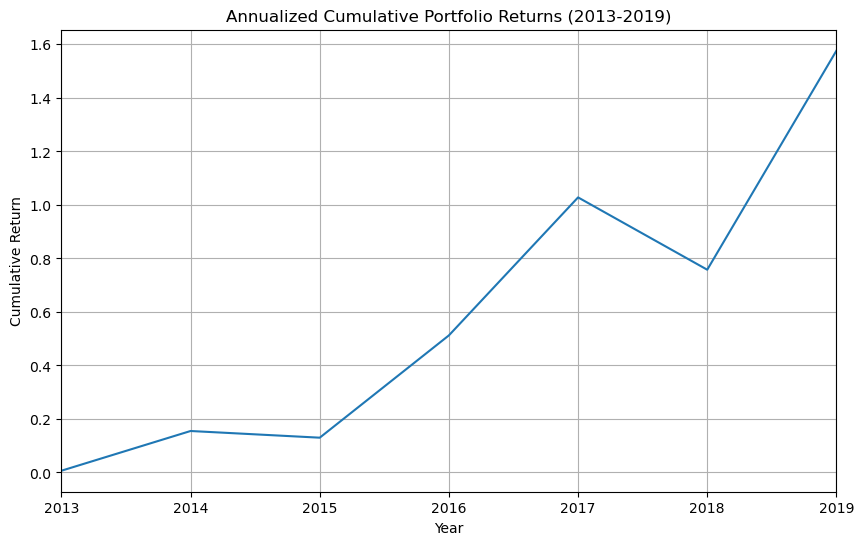

In [13]:
# Visualization 1: Annualized cumulative returns
cumulative_returns = (1 + portfolio_returns_daily['Portfolio_Return']).cumprod() - 1
annualized_returns = cumulative_returns.resample('Y').last()  # Take the last value of each year

# Plot annualized cumulative returns
plt.figure(figsize=(10, 6))
annualized_returns.plot()
plt.title("Annualized Cumulative Portfolio Returns (2013-2019)")
plt.xlabel("Year")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

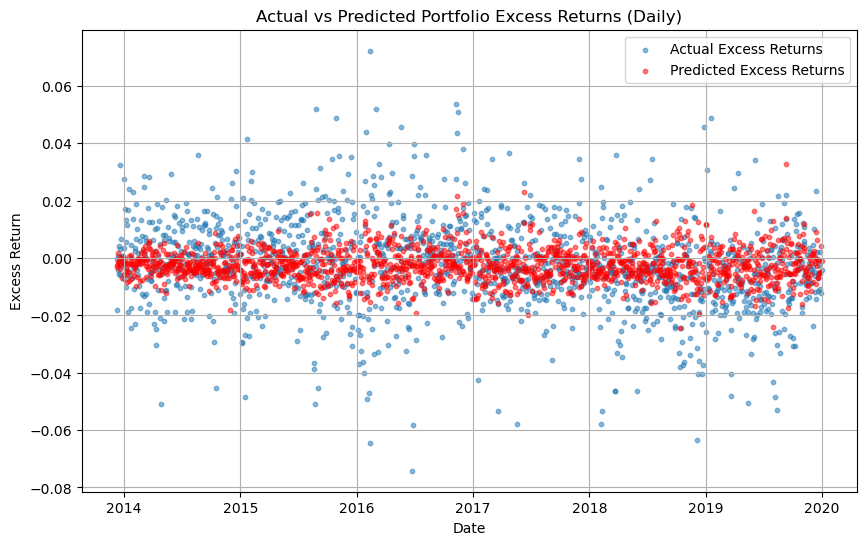

In [14]:
predicted_excess_returns = results.fittedvalues
plt.figure(figsize=(10, 6))
plt.scatter(data_for_regression.index, y, label="Actual Excess Returns", alpha=0.5, s=10)
plt.scatter(data_for_regression.index, predicted_excess_returns, color='red', label="Predicted Excess Returns", alpha=0.5, s=10)
plt.title("Actual vs Predicted Portfolio Excess Returns (Daily)")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.show()